# Lesson 7.3 — Singularity-Robust Resolved Rates
**Module 6 · Unit 7 · Lesson 27**

Apply DLS to inverse velocity kinematics: q̇ = J⁺_λ ξ stays bounded where the pseudoinverse blows up; the small tracking error sits in the lost direction. (Kinematic trade-off, not feedback.)

In [1]:
import numpy as np
def dh(th,d,a,al):
    ct,st,ca,sa=np.cos(th),np.sin(th),np.cos(al),np.sin(al)
    return np.array([[ct,-st*ca,st*sa,a*ct],[st,ct*ca,-ct*sa,a*st],[0,sa,ca,d],[0,0,0,1]])
def forward_chain(P,T,q):
    M=np.eye(4); Ms=[M.copy()]
    for i,(th0,d0,a,al) in enumerate(P):
        th,d=(th0+q[i],d0) if T[i]=="R" else (th0,d0+q[i]); M=M@dh(th,d,a,al); Ms.append(M.copy())
    return Ms
def geometric_jacobian(P,T,q):
    Ms=forward_chain(P,T,q); on=Ms[-1][:3,3]; J=np.zeros((6,len(q)))
    for i in range(len(q)):
        z=Ms[i][:3,2]; o=Ms[i][:3,3]
        if T[i]=="R": J[:3,i]=np.cross(z,on-o); J[3:,i]=z
        else: J[:3,i]=z
    return J
def Jv_planar(P,T,q): return geometric_jacobian(P,T,q)[:2,:]
def fk_xy(P,T,q):
    M=forward_chain(P,T,q)[-1]; return M[:2,3].copy()
def dls_inv(J,lam): return J.T@np.linalg.inv(J@J.T+lam**2*np.eye(J.shape[0]))
P2=[(0,0,1,0),(0,0,1,0)]; T2=["R","R"]
P3=[(0,0,1,0),(0,0,1,0),(0,0,0.6,0)]; T3=["R","R","R"]


## DLS keeps joint rates bounded near a singularity

theta2=0.60  ||qdot|| pinv=   3.79  dls=3.314
theta2=0.30  ||qdot|| pinv=   7.49  dls=4.797
theta2=0.15  ||qdot|| pinv=  14.92  dls=4.625
theta2=0.08  ||qdot|| pinv=  27.96  dls=3.171
theta2=0.04  ||qdot|| pinv=  55.91  dls=1.733


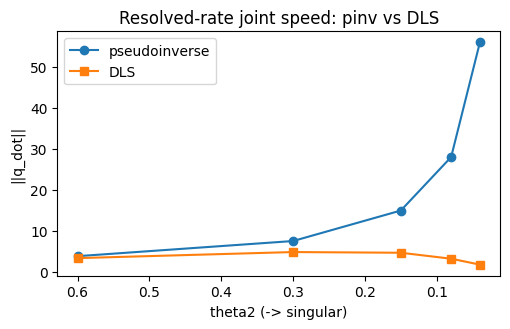

In [2]:
import matplotlib.pyplot as plt
checks=[]; lam=0.1
t2s=np.array([0.6,0.3,0.15,0.08,0.04]); pinvn=[]; dlsn=[]
for t2 in t2s:
    J=Jv_planar(P2,T2,np.array([0.4,t2])); U,S,Vt=np.linalg.svd(J); xi=U[:,1]   # lost direction
    pinvn.append(np.linalg.norm(np.linalg.pinv(J)@xi))
    dlsn.append(np.linalg.norm(dls_inv(J,lam)@xi))
    print(f"theta2={t2:4.2f}  ||qdot|| pinv={pinvn[-1]:7.2f}  dls={dlsn[-1]:.3f}")
checks.append(dlsn[-1] < pinvn[-1] and dlsn[-1] < 1/(2*lam)+1)
plt.figure(figsize=(5.2,3.4)); plt.plot(t2s,pinvn,'o-',label='pseudoinverse'); plt.plot(t2s,dlsn,'s-',label='DLS')
plt.gca().invert_xaxis(); plt.xlabel('theta2 (-> singular)'); plt.ylabel('||q_dot||'); plt.legend(); plt.title('Resolved-rate joint speed: pinv vs DLS'); plt.tight_layout(); plt.show()

## The DLS tracking error is small and sits in the lost direction

In [3]:
J=Jv_planar(P2,T2,np.array([0.4,0.08])); U,S,Vt=np.linalg.svd(J); xi=U[:,1]
qd=dls_inv(J,lam)@xi; err=xi-J@qd
print("commanded xi:",np.round(xi,3),"  achieved:",np.round(J@qd,3))
print("error vector:",np.round(err,3)," (aligned with lost direction u_min=",np.round(U[:,1],3),")")
checks.append(np.linalg.norm(err) < 1.0 and abs(np.dot(err/np.linalg.norm(err),U[:,1]))>0.9)
assert all(checks), f"FAILED: {checks}"
print("All checks passed.")

commanded xi: [0.901 0.433]   achieved: [0.102 0.049]
error vector: [0.799 0.384]  (aligned with lost direction u_min= [0.901 0.433] )
All checks passed.
